In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 60 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 30s/step - accuracy: 0.5571 - loss: 2.8794 - val_accuracy: 0.9000 - val_loss: 0.3584
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step - accuracy: 0.7960 - loss: 0.8390 - val_accuracy: 0.8500 - val_loss: 0.4267
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step - accuracy: 0.8813 - loss: 0.5975 - val_accuracy: 0.9000 - val_loss: 0.4415
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 912ms/step - accuracy: 0.9095 - loss: 0.5318 - val_accuracy: 0.9000 - val_loss: 0.3587
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step - accuracy: 0.9206 - loss: 0.1594 - val_accuracy: 0.9500 - val_loss: 0.0674
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 849ms/step - accuracy: 0.9778 - loss: 0.0981 - val_accuracy: 0.9500 - val_loss: 0.0784
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step - accuracy: 0.9674 - loss: 0.1558 - val_accuracy: 0.9500 - val_loss: 0.0761
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step - accuracy: 0.9785 - loss: 0.0987 - val_accuracy: 0.9000 - val_loss: 

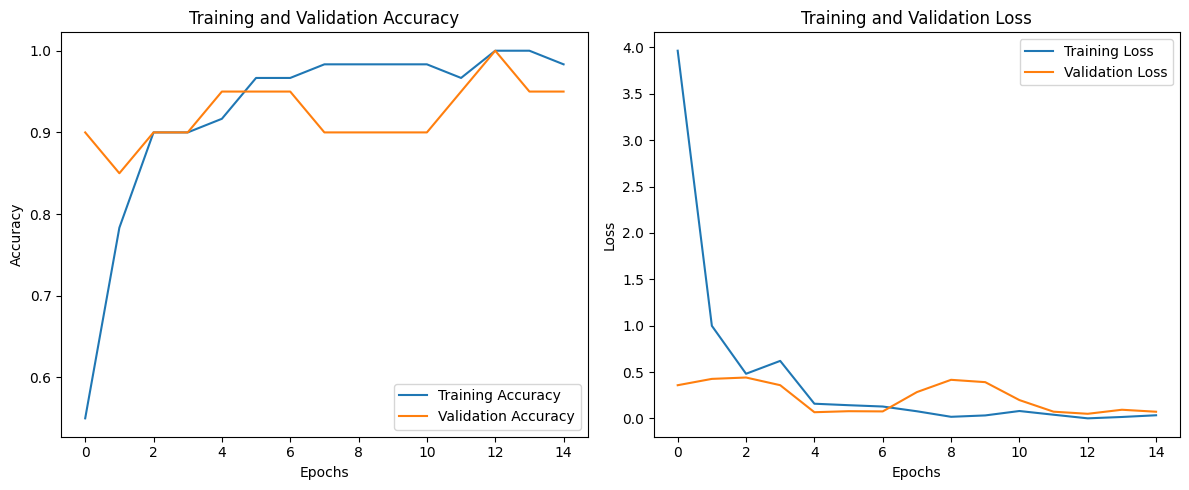

Found 20 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 1.0000 - loss: 8.5385e-04
Test Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step


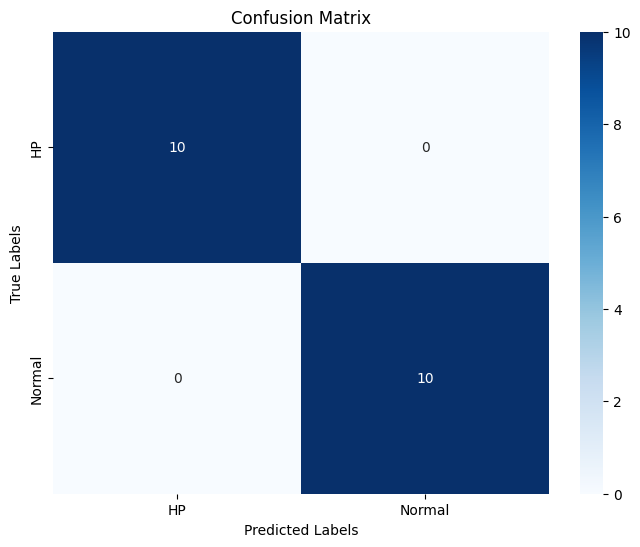

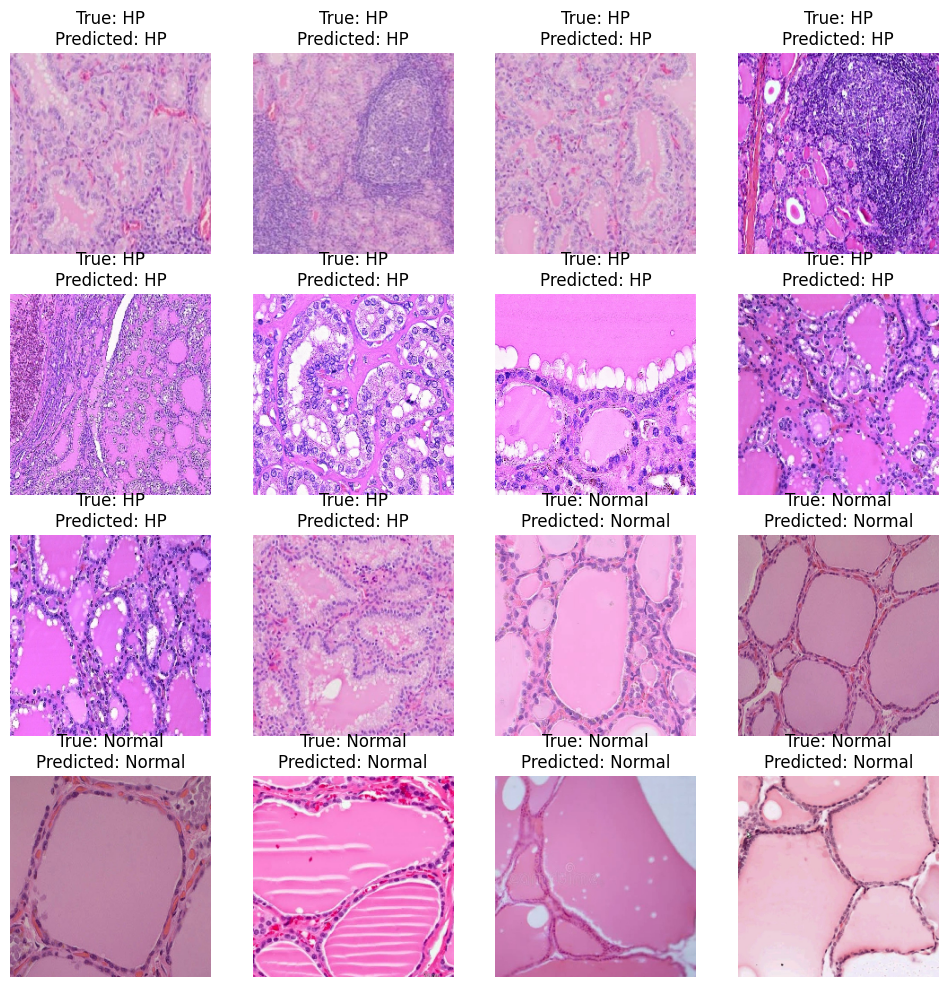

In [ ]:
# Step 1: Import Required Tools (Libraries)
import tensorflow as tf
import matplotlib.pyplot as plt #graph
import numpy as np
import seaborn as sns #something related to image
from sklearn.metrics import confusion_matrix

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 2: Load the VGG16 model, excluding the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = Flatten()(base_model.output)  # Add custom layers on top of the base model
x = Dense(256, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x) # 2 is number of categories ex. cancer and non-cancer

model = Model(inputs=base_model.input, outputs=predictions) # Define the complete model

for layer in base_model.layers:   # Freeze the layers of the base model
    layer.trainable = False

# Step 3: Build the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 4: Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255)   # Preprocessing for validation data

# Step 5: Load and preprocess training data and validation data

train_data = train_datagen.flow_from_directory(       # Load and preprocess training data
    '/content/drive/MyDrive/graves disease /Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(           # Load and preprocess validation data
    '/content/drive/MyDrive/graves disease /Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Step 6: Train the model
history = model.fit(train_data, epochs = 15, validation_data=val_data)

# Step 7: Plot Accuracy and Loss graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)    # Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)    # Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Step 8: Preprocessing for test data
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load and preprocess test data
test_data = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/graves disease /Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc}")

# Predict the classes for test data
predictions = model.predict(test_data)

# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=1)

# Convert true labels to class labels
true_classes = test_data.classes

# Get the mapping of indices to class labels
class_labels = list(test_data.class_indices.keys())

# Convert predicted class indices to class labels
predicted_labels = [class_labels[idx] for idx in predicted_classes]

# Convert true class indices to class labels
true_labels = [class_labels[idx] for idx in true_classes]

# Create and plot the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# Step 8: Visualize the predictions along with the images
def show_images_with_labels(images, predicted_labels, class_labels, true_labels):
    plt.figure(figsize=(12, 12))
    for i in range(min(len(images), 16)):
        plt.subplot(4, 4, i+1)
        plt.imshow(images[i])
        plt.title(f"True: {true_labels[i]}\nPredicted: {predicted_labels[i]}")
        plt.axis('off')
    plt.show()

# Load some test images and display them with their predictions
test_images, _ = next(test_data)  # Get a batch of images using `next`

# Show final outputs
show_images_with_labels(test_images, predicted_labels[:16], class_labels, true_labels[:16])


In [ ]:
from tensorflow.keras.preprocessing import image
# Get the mapping of class indices to class labels
class_labels = list(test_data.class_indices.keys())

# Function to preprocess and predict a single image
def preprocess_and_predict(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Rescale the image (as done during training)

    # Make predictions
    predictions = model.predict(img_array)
    predicted_class = tf.argmax(predictions, axis=1).numpy()[0]  # Get the predicted class index

    # Display the image with the predicted label
    plt.imshow(img)
    plt.title(f"Predicted: {class_labels[predicted_class]}")
    plt.axis('off')
    plt.show()

# Test with a new image
img_path = '/graves.jpg'  ## Replace with the path to your image
preprocess_and_predict(img_path)


FileNotFoundError: [Errno 2] No such file or directory: '/graves.jpg'

In [ ]:
# Save the model to a file
model.save('/content/drive/MyDrive/C - Graves_disease.h5')
